In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.3 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 2.4 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 2.5 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 2.6 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 2.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 2.4 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 2.3 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.1 MB 2.3 MB/s eta 0:00:02
   -----------------------

Ridge & Lasso Regression

In [6]:
from sklearn.datasets import fetch_california_housing

In [8]:
df = fetch_california_housing()
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [10]:
dataset1 = pd.DataFrame(df.data)
print(dataset1)

            0     1         2         3       4         5      6       7
0      8.3252  41.0  6.984127  1.023810   322.0  2.555556  37.88 -122.23
1      8.3014  21.0  6.238137  0.971880  2401.0  2.109842  37.86 -122.22
2      7.2574  52.0  8.288136  1.073446   496.0  2.802260  37.85 -122.24
3      5.6431  52.0  5.817352  1.073059   558.0  2.547945  37.85 -122.25
4      3.8462  52.0  6.281853  1.081081   565.0  2.181467  37.85 -122.25
...       ...   ...       ...       ...     ...       ...    ...     ...
20635  1.5603  25.0  5.045455  1.133333   845.0  2.560606  39.48 -121.09
20636  2.5568  18.0  6.114035  1.315789   356.0  3.122807  39.49 -121.21
20637  1.7000  17.0  5.205543  1.120092  1007.0  2.325635  39.43 -121.22
20638  1.8672  18.0  5.329513  1.171920   741.0  2.123209  39.43 -121.32
20639  2.3886  16.0  5.254717  1.162264  1387.0  2.616981  39.37 -121.24

[20640 rows x 8 columns]


In [11]:
dataset1.columns = df.feature_names
print(dataset1)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [12]:
dataset1['MedHouseVal'] = df.target
dataset1


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [17]:
X = dataset1.iloc[:,:-1]
y = dataset1.iloc[:,-1]

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [18]:
lin_reg = LinearRegression()
mse = cross_val_score(lin_reg, X,y, scoring='neg_mean_squared_error', cv=5)
mean_mse = np.mean(mse)
print(mean_mse)

-0.5582901717686554


In [27]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
parameters = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-3,1e-2,1e-1,1,1.1,2,3,4,10,20,30,40,50,60,65,69,70,71,75,79,80,81,85,90,95,100]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1e-15, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [28]:
results_df = pd.DataFrame(ridge_regressor.cv_results_)
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011364,0.001531,0.004116,0.000642,1.000000e-15,{'alpha': 1e-15},-0.484859,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,30
1,0.009575,0.001350,0.003536,0.000716,1.000000e-10,{'alpha': 1e-10},-0.484859,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,29
2,0.008426,0.000068,0.003275,0.000296,1.000000e-08,{'alpha': 1e-08},-0.484859,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,28
3,0.008775,0.000769,0.003124,0.000181,1.000000e-05,{'alpha': 1e-05},-0.484859,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,27
4,0.008499,0.000453,0.003048,0.000225,1.000000e-03,{'alpha': 0.001},-0.484858,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,26
5,0.008596,0.000440,0.003037,0.000223,1.000000e-02,{'alpha': 0.01},-0.484857,-0.622498,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,25
6,0.008353,0.000330,0.003184,0.000211,1.000000e-01,{'alpha': 0.1},-0.484845,-0.622501,-0.646210,-0.543206,-0.494682,-0.558289,0.065606,24
7,0.009427,0.001395,0.003222,0.000211,1.000000e+00,{'alpha': 1},-0.484727,-0.622537,-0.646210,-0.543260,-0.494661,-0.558279,0.065641,23
8,0.008931,0.000842,0.003257,0.000433,1.100000e+00,{'alpha': 1.1},-0.484714,-0.622541,-0.646210,-0.543266,-0.494658,-0.558278,0.065645,22
9,0.008482,0.000497,0.003292,0.000383,2.000000e+00,{'alpha': 2},-0.484596,-0.622576,-0.646210,-0.543320,-0.494637,-0.558268,0.065680,21


In [29]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 71}
-0.5579295537432541


In [44]:
print(ridge_regressor.best_estimator_.coef_)

[ 4.30407230e-01  9.54783842e-03 -9.52523778e-02  5.80898280e-01
 -3.55796517e-06 -3.77582126e-03 -4.19851461e-01 -4.32126321e-01]


In [31]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso = Lasso()
parameters = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-3,1e-2,1e-1,1,1.1,2,3,4,10,20,30,40,50,60,65,69,70,71,75,79,80,81,85,90,95,100]}
lasso_regressor = GridSearchCV(lasso, parameters, scoring='neg_mean_squared_error',cv=5)
lasso_regressor.fit(X,y)


d:\AURKO\jupyter machine learning\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.960e+02, tolerance: 2.228e+00
  model = cd_fast.enet_coordinate_descent(
d:\AURKO\jupyter machine learning\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.229e+03, tolerance: 2.256e+00
  model = cd_fast.enet_coordinate_descent(
d:\AURKO\jupyter machine learning\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1e-15, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [43]:
print(lasso_regressor.best_estimator_.coef_)

[ 4.33009442e-01  9.50408826e-03 -1.00223808e-01  6.07990654e-01
 -3.70321981e-06 -3.77149036e-03 -4.20103241e-01 -4.32734461e-01]


In [32]:
results_df = pd.DataFrame(lasso_regressor.cv_results_)
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.536955,0.064644,0.003912,0.000569,1.000000e-15,{'alpha': 1e-15},-0.484859,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,5
1,0.633420,0.047265,0.003669,0.000573,1.000000e-10,{'alpha': 1e-10},-0.484859,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,4
2,0.494393,0.054725,0.003932,0.000577,1.000000e-08,{'alpha': 1e-08},-0.484859,-0.622497,-0.646210,-0.543200,-0.494685,-0.558290,0.065602,3
3,0.322450,0.034271,0.003514,0.000367,1.000000e-05,{'alpha': 1e-05},-0.484828,-0.622511,-0.646209,-0.543222,-0.494676,-0.558289,0.065612,2
4,0.215756,0.026320,0.003720,0.001070,1.000000e-03,{'alpha': 0.001},-0.481887,-0.623943,-0.646141,-0.545509,-0.493898,-0.558276,0.066596,1
5,0.179614,0.017300,0.003364,0.000261,1.000000e-02,{'alpha': 0.01},-0.467077,-0.640151,-0.650419,-0.570761,-0.491709,-0.564023,0.074744,6
6,0.066584,0.025512,0.003402,0.000377,1.000000e-01,{'alpha': 0.1},-0.523701,-0.668057,-0.702928,-0.718168,-0.699453,-0.662461,0.071267,7
7,0.013232,0.000826,0.003484,0.000343,1.000000e+00,{'alpha': 1},-0.941529,-0.850291,-1.155776,-0.961345,-1.102418,-1.002272,0.111405,8
8,0.014607,0.001588,0.003338,0.000210,1.100000e+00,{'alpha': 1.1},-1.010533,-0.899022,-1.239615,-1.009000,-1.185417,-1.068718,0.125358,9
9,0.010614,0.000504,0.003067,0.000046,2.000000e+00,{'alpha': 2},-1.336349,-1.197017,-1.571269,-1.257018,-1.514036,-1.375138,0.144875,27


In [33]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 0.001}
-0.5582759293868979


In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=0)

In [36]:
prediction_lasso = lasso_regressor.predict(X_test)
prediction_ridge = ridge_regressor.predict(X_test)

C:\Users\AurKo\AppData\Local\Temp\ipykernel_4904\1028230056.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-prediction_lasso)


<Axes: xlabel='MedHouseVal', ylabel='Density'>

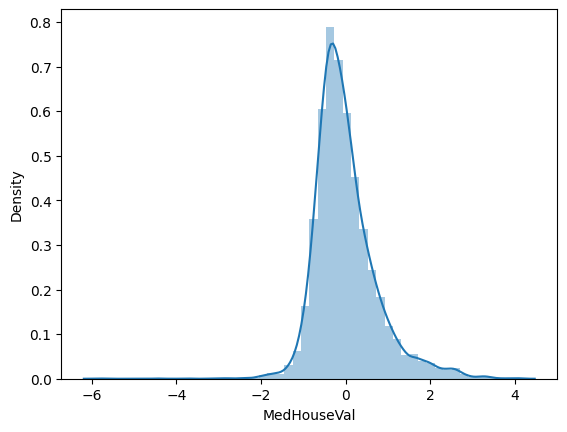

In [39]:
sns.distplot(y_test-prediction_lasso)

C:\Users\AurKo\AppData\Local\Temp\ipykernel_4904\1693200975.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-prediction_ridge)


<Axes: xlabel='MedHouseVal', ylabel='Density'>

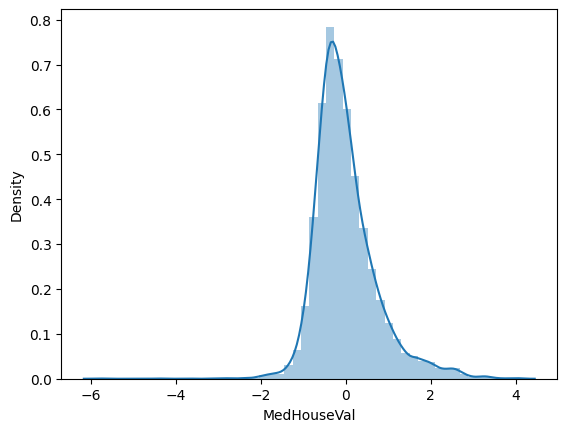

In [40]:
sns.distplot(y_test-prediction_ridge)

Multiple Linear Regression

In [45]:
dataset2 = pd.read_csv('50_Startups.csv')
dataset2

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [46]:
X = dataset2.iloc[:,:-1]
y = dataset2.iloc[:,-1]


In [49]:
states = pd.get_dummies(X['State'], drop_first=True, dtype=int)
states

,Florida,New York
0,0,1
1,0,0
2,1,0
3,0,1
4,1,0
5,0,1
6,0,0
7,1,0
8,0,1
9,0,0


In [50]:
X = X.drop('State',axis=1)
X = pd.concat([X, states], axis=1)
X

,R&D Spend,Administration,Marketing Spend,Florida,New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=0)

In [52]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
y_pred = regressor.predict(X_test)

In [54]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.9347068473282423

Multi Collinearity in Linear Regression

In [56]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 3.5 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 4.3 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 4.9 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 5.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.2 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------

In [59]:
import statsmodels.api as sm
df_adv = pd.read_csv('Advertising.csv', index_col=0)
df_adv

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [60]:
X = df_adv.iloc[:,:-1]
y = df_adv.iloc[:,-1]
X

,TV,radio,newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4
...,...,...,...
196,38.2,3.7,13.8
197,94.2,4.9,8.1
198,177.0,9.3,6.4
199,283.6,42.0,66.2


In [61]:
X = df_adv[['TV','radio','newspaper']]
y = df_adv['sales']
X

,TV,radio,newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4
...,...,...,...
196,38.2,3.7,13.8
197,94.2,4.9,8.1
198,177.0,9.3,6.4
199,283.6,42.0,66.2


In [62]:
X = sm.add_constant(X)
X

,const,TV,radio,newspaper
1,1.0,230.1,37.8,69.2
2,1.0,44.5,39.3,45.1
3,1.0,17.2,45.9,69.3
4,1.0,151.5,41.3,58.5
5,1.0,180.8,10.8,58.4
...,...,...,...,...
196,1.0,38.2,3.7,13.8
197,1.0,94.2,4.9,8.1
198,1.0,177.0,9.3,6.4
199,1.0,283.6,42.0,66.2


Ordinary Least Squares (OLS) regression is a fundamental linear modeling technique that estimates parameters by minimizing the sum of the squared differences (residuals) between observed and predicted values. It acts as a Best Linear Unbiased Estimator (BLUE) for predicting numerical outcomes by determining the "best-fit" line. 

In [63]:
model = sm.OLS(y, X).fit()

In [64]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.58e-96
Time:                        21:04:12   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
radio          0.1885      0.009     21.893      0.000       0.172       0.206
newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [65]:
X.iloc[:,1:].corr()

,TV,radio,newspaper
TV,1.000000,0.054809,0.056648
radio,0.054809,1.000000,0.354104
newspaper,0.056648,0.354104,1.000000


So, no multicollinearity 

In [66]:
df_salary = pd.read_csv('Salary_Data.csv')
df_salary

,YearsExperience,Age,Salary
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891
5,2.9,23.0,56642
6,3.0,23.0,60150
7,3.2,23.3,54445
8,3.2,23.3,64445
9,3.7,23.6,57189


In [67]:
X = df_salary[['YearsExperience','Age']]
y = df_salary['Salary']
X

,YearsExperience,Age
0,1.1,21.0
1,1.3,21.5
2,1.5,21.7
3,2.0,22.0
4,2.2,22.2
5,2.9,23.0
6,3.0,23.0
7,3.2,23.3
8,3.2,23.3
9,3.7,23.6


In [68]:
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()

In [70]:
X.head(5)

,const,YearsExperience,Age
0,1.0,1.1,21.0
1,1.0,1.3,21.5
2,1.0,1.5,21.7
3,1.0,2.0,22.0
4,1.0,2.2,22.2


In [69]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     323.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.35e-19
Time:                        21:20:01   Log-Likelihood:                -300.35
No. Observations:                  30   AIC:                             606.7
Df Residuals:                      27   BIC:                             610.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -6661.9872   2.28e+04     -0.292      0.773   -5.35e+04    4.02e+04
YearsExperience  6153.3533   2337.092      2.633      0.014    1358.037    1.09e+04
Age              1836.0136   1285.034      1.429      0.165    -800.659    4472.686
==============================================================================
Omnibus:                        2.695   Durbin-Watson:                   1.711
Prob(Omnibus):                  0.260   Jarque-Bera (JB):                1.975
Skew:                           0.456   Prob(JB):                        0.372
Kurtosis:                       2.135   Cond. No.                         626.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [71]:
X.iloc[:,1:].corr()

,YearsExperience,Age
YearsExperience,1.000000,0.987258
Age,0.987258,1.000000


as experience and age has more than 90% correlation, we can drop age(p value not less than 0.05) and do the regression only with experience